# A feladat

Az adathalmaz az USA ingatlanbérlési piacáról tartalmaz információkat. Az adathalmazt szűrni kell a: a lényegtelen, vagy nehezen felhasználható feature-öket el kell dobni, a hiányzó értékeket esetenként pótolni kell, és esetleges dimneziócsökkentést is el lehet végezni. A végső adathalmazból a bérlési ár (price) mezőt kell majd regresszióval kiszámolni, az egyéb, megtisztított bemeneti paraméterekkel. A tanító és tesztelő részek 75-25 arányban lesznek elosztva a teljes adathalmazon.

### Adathalmaz

Elérhetősége: https://archive.ics.uci.edu/dataset/555/apartment+for+rent+classified
Az adathalmaz nem tölthető le, egy python script segítségével lett csv-vé konvertálva.

Csak az USA-ban található ingatlan bérbeadási hirdetéseket tartalmazza, több oldalról/szolgáltatótól összeszedve.
10 valamint 100 ezer rekordos verziók is elérhetőek. A project során a 100 ezres adathalmaz lesz felhasználva.

### Feature-ök:
1. category: hirdetés kategóriája, string
2. title: hirdetés címe, string
3. body: hirdetés szövege, string
4. amenities: különleges felszereltségek listája, string, sok hiányzó érték
5. bathrooms: fürdők száma
6. bedrooms: hálószobák száma
7. currency: pénznem, minden értelmes értéket tartalmazó mező USD
8. fee: díj (nincs egyéb leírás, hogy mié), integer vagy igen/nem vagy hiányzó érték
9. has_photo: hirdetésben szereplő fotók kategóriája, van/nincs vagy csak “Thumbnail” vagy hiányzó érték
10.pets_allowed: milyen állatok megengedettek, string
11.price: ára, double, kiszámítandó érték
12.price_display: hirdetésben megjelenített ára, integer, egyezik a price-al
13.price_type: fizetési gyakoriság, “Monthly” vagy “Weekly” vagy hiányzó érték
14. square_feet: alapterület, integer hiányzó érték
15.address: cím, string
16.cityname: város neve, string
17. state: állam neve, string
18.latitude: szélességi fok, double
19.longitude: hosszúsági fok, double
20. source: honnan van a hirdetés, string, 26 egyedi érték
21. time: a hirdetés feladásának ideje, unix timestamp seconds formátumban megadva, 2018-2020 közötti értékek

# Előkészítés

In [3]:
# Csomag importálás, alapbeállítások

library(tidyverse, warn.conflicts=FALSE)
library(recipes, warn.conflicts=FALSE)
library(lubridate, warn.conflicts=FALSE)
library(corrplot, warn.conflicts=FALSE)
library(ggplot2, warn.conflicts=FALSE)
library(dplyr, warn.conflicts=FALSE)

options(repr.plot.width=8, repr.plot.height=6)

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'tidyr' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"
Warning message:
"package 'forcats' was built under R version 4.5.3"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the con

In [4]:
# Adatok beolvasása

df = read_csv("./../data/apartment_data.csv",
              col_types=list(
                  currency = col_factor(),
                  bathrooms = col_double(),
                  bedrooms = col_double(),
                  price_display = col_double(),
                  square_feet = col_double()
              ))

Warning message:
"One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)"


# Adatelemzés, tisztítás, ábrázolás

In [5]:
# Alapvető statisztikák az adathalmazról

summary(df)

   category            title               body            amenities        
 Length:99826       Length:99826       Length:99826       Length:99826      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
   bathrooms        bedrooms          currency         fee           
 Min.   :1.000   Min.   :0.000   USD      :99820   Length:99826      
 1st Qu.:1.000   1st Qu.:1.000   Cats,Dogs:    1   Class :character  
 Median :1.000   Median :2.000   1019     :    1   Mode  :character  
 Mean   :1.445   Mean   :1.728   NA's     :    4                     
 3rd Qu.:2.000   3rd Qu.:2.000    

In [6]:
# Vizsgálat a hibákra
glimpse(df)

head(problems(df), 20)

# Konklúzió
# Úgy néz ki sok hiba a soreltolódás miatt van, ezeket ki kell szűrni

Rows: 99,826
Columns: 21
$ category      <chr> "housing/rent/apartment", "housing/rent/apartment", "hou…
$ title         <chr> "One BR 507 & 509 Esplanade", "Three BR 146 Lochview Dri…
$ body          <chr> "This unit is located at 507 & 509 Esplanade, Redondo Be…
$ amenities     <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ bathrooms     <dbl> 1.0, 1.5, 2.0, 1.0, 1.0, 1.5, 2.0, 2.0, 1.0, 2.0, 2.5, 3…
$ bedrooms      <dbl> 1, 3, 3, 2, 1, 2, 2, 2, 2, 2, 3, 2, 2, 4, 3, 2, 1, 1, 3,…
$ currency      <fct> "USD", "USD", "USD", "USD", "USD", "USD", "USD", "USD", …
$ fee           <chr> "No", "No", "No", "No", "No", "No", "No", "No", "No", "N…
$ has_photo     <chr> "Thumbnail", "Thumbnail", "Thumbnail", "Thumbnail", "Thu…
$ pets_allowed  <chr> "Cats", "Cats,Dogs", NA, "Cats,Dogs", "Cats,Dogs", "Cats…
$ price         <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ price_display <dbl> 2195, 1250, 1395, 1600, 975, 1250, 1600, 1300, 795, 2150…
$ price_type   

row,col,expected,actual,file
<int>,<int>,<chr>,<chr>,<chr>
6731,12,a double,"$1,560 Weekly",D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
7247,12,a double,$275 Monthly|Weekly,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,5,a double,No,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,6,a double,Thumbnail,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
8810,14,a double,NJ,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,5,a double,No,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,6,a double,Thumbnail,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
33782,14,a double,CA,D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv
50213,12,a double,"$8,500 Weekly",D:/Dokumentumok/MSc/F2_AdatTar/beadando/EX9BLV_ABTG/data/apartment_data.csv


In [7]:
# Adattisztítás a summary alapján
dfc = df

# Adatok eltolódása miatt keletkezett sorok szűrése
# Minden sorban USD-nek kellene szerepellnie, így használható szűrésre
dfc = filter(dfc, currency == "USD")

# NA-k feltöltése/szűrése
dfc = drop_na(dfc, price, price_display, square_feet, latitude, longitude)
dfc = replace_na(dfc,
                 list(bathrooms = median(df$bathrooms, na.rm=TRUE),
                 bedrooms = median(df$bedrooms, na.rm=TRUE),
                 pets_allowed = "None"))

# Nem értelmezett értékek szűrése
dfc = filter(dfc,
             grepl("housing/rent", category, fixed = TRUE), # csak kiadó lakások legyenek
             price_type %in% c("Monthly", "Weekly")) # csak diszkrét kategóriák legyenek

# Kategorizálás
dfc = mutate(dfc,
             category = factor(category),
             fee = factor(fee),
             has_photo = factor(has_photo),
             pets_allowed = fct_collapse(pets_allowed,
                Yes = c("Cats", "Cats,Dogs", "Cats,Dogs,None", "Dogs"),
                No = c("None")),
             price_type = factor(price_type),
             state = factor(state),
             cityname = factor(cityname),
             source = factor(source))

# Felhasználatlan/felesleges mezők szűrése
dfc = select(dfc, -title, -body, -currency, -address)

summary(dfc)

# price_type-ban 1 érték maradt, kivehető
dfc = select(dfc, -price_type)

                           category      amenities           bathrooms    
 housing/rent                  :    7   Length:99762       Min.   :1.000  
 housing/rent/apartment        :99701   Class :character   1st Qu.:1.000  
 housing/rent/commercial/retail:   42   Mode  :character   Median :1.000  
 housing/rent/condo            :    3                      Mean   :1.445  
 housing/rent/home             :    4                      3rd Qu.:2.000  
 housing/rent/other            :    1                      Max.   :9.000  
 housing/rent/short_term       :    4                                     
    bedrooms      fee            has_photo     pets_allowed     price      
 Min.   :0.000   No :99561   No       : 9256   Yes:39148    Min.   :  100  
 1st Qu.:1.000   Yes:  201   Thumbnail:34348   No :60614    1st Qu.: 1014  
 Median :2.000               Yes      :56158                Median : 1350  
 Mean   :1.728                                              Mean   : 1527  
 3rd Qu.:2.000      

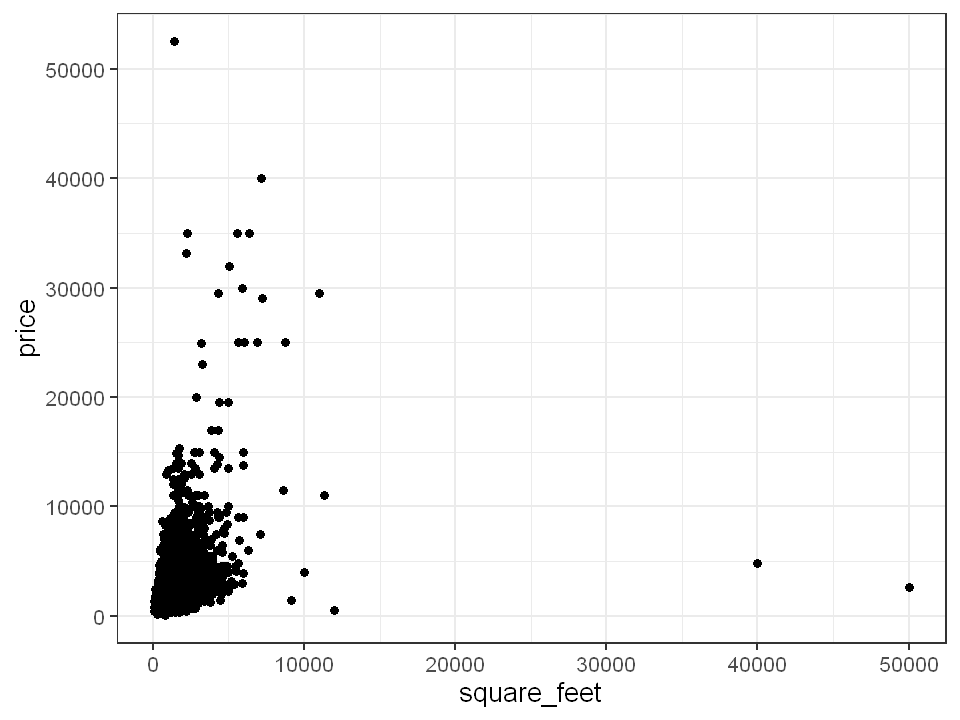

In [8]:
# Kiugró értékek keresése

ggplot(data = dfc) +
geom_point(mapping = aes(x = square_feet, y = price)) +
theme_bw(base_size=16)

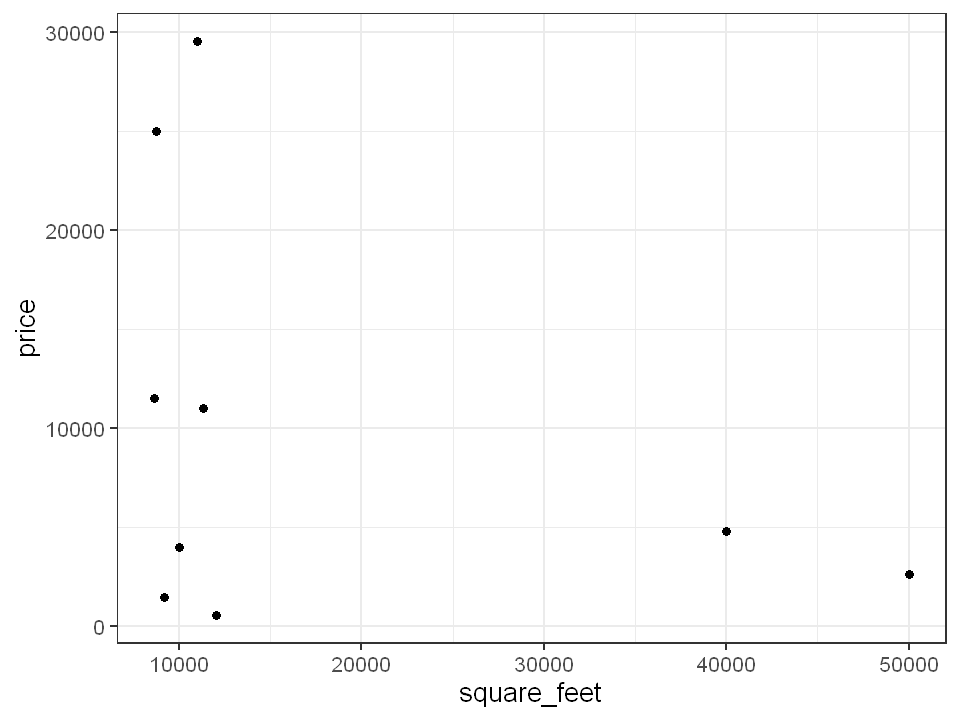

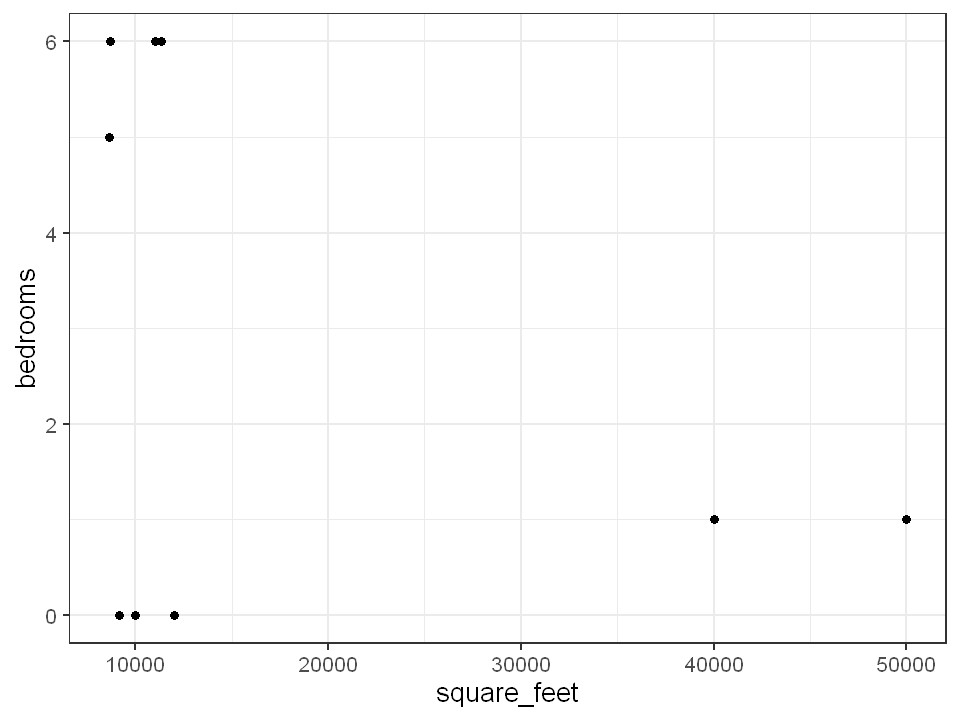

In [9]:
# Kiugró értékek keresése 2

# A magas értékek vizsgálata
dfc %>%
filter(square_feet > 8000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = price)) +
theme_bw(base_size=16)

dfc %>%
filter(square_feet > 8000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = bedrooms)) +
theme_bw(base_size=16)

# Konklúzió:
# Nem feltétlenül irreális értékek. Lehetséges, hogy telkekről
# és nagy villákról van szó (10000ft^2 ~ 900m^2)

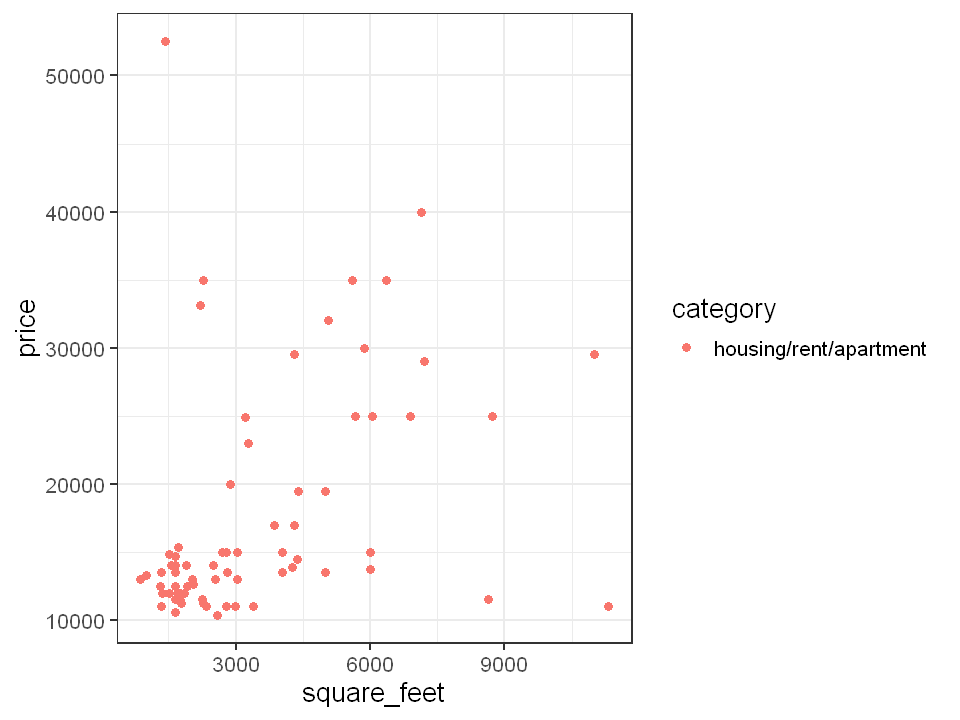

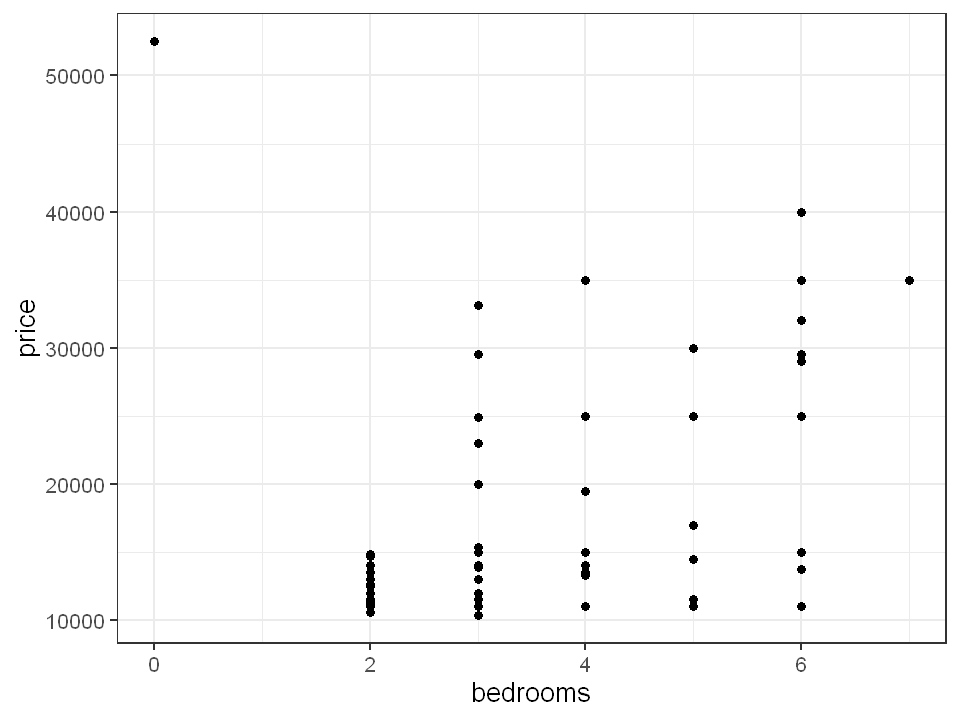

In [10]:
# Kiugró értékek keresése 3

# A magas értékek vizsgálata
dfc %>%
filter(price > 10000) %>%
ggplot() +
geom_point(mapping = aes(x = square_feet, y = price, color = category)) +
theme_bw(base_size=16)

dfc %>%
filter(price > 10000) %>%
ggplot() +
geom_point(mapping = aes(x = bedrooms, y = price)) +
theme_bw(base_size=16)

# Konklúzió:
# Ezek sem feltétlenül irreális értékek, kivéve a legdrágábbat. Lehetséges, hogy luxus villák is vannak hirdetve

dfc = filter(dfc, price < 50000)

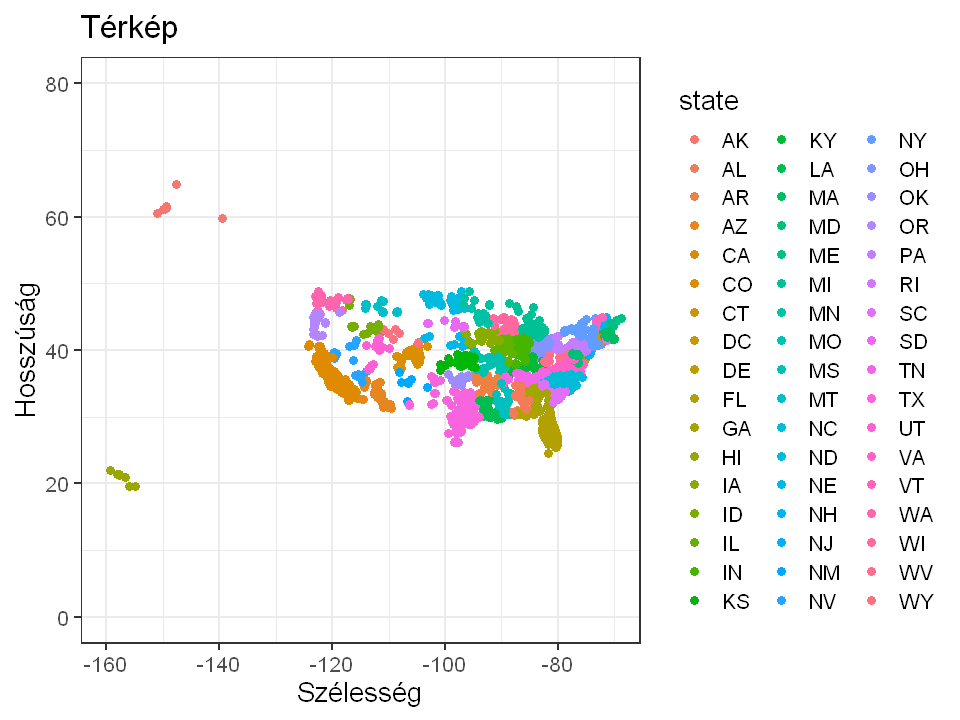

In [10]:
# Lat, long és state vizsgálat

dfc %>%
filter(!is.na(state)) %>%
ggplot() +
geom_point(mapping = aes(x = longitude, y = latitude, color = state)) +
coord_cartesian(xlim=c(-160,-70), ylim=c(0,80)) +
xlab("Szélesség") +
ylab("Hosszúság") +
ggtitle("Térkép") + 
theme_bw(base_size = 16)

# Konklúzió:
# Nincs kiugró érték, szépen látszanak az államok, és az USA térképe is kirajzolódik

In [11]:
# Amenities (felszereltség) kategória kezelése

dfc %>% 
filter(!is.na(amenities)) %>%
select(amenities) %>%
count(amenities) %>%
filter(n > 150) %>%
arrange(desc(n))

amenities,n
<chr>,<int>
Parking,6204
"Parking,Storage",2117
"Gym,Pool",1873
Pool,1483
"Gym,Parking,Pool",1191
"Parking,Pool",889
Washer Dryer,843
Patio/Deck,776
"Clubhouse,Gym,Pool",768


parking,storage,gym,pool,washer,patio,club,wood_floor,tv,tv_signal,dish_washer,fridge,luxury,gated,playground,frire,ac,tennis
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
43961,21670,37425,43642,26068,26581,19151,8903,4497,12542,16646,14947,211,8665,11358,14957,15835,8514


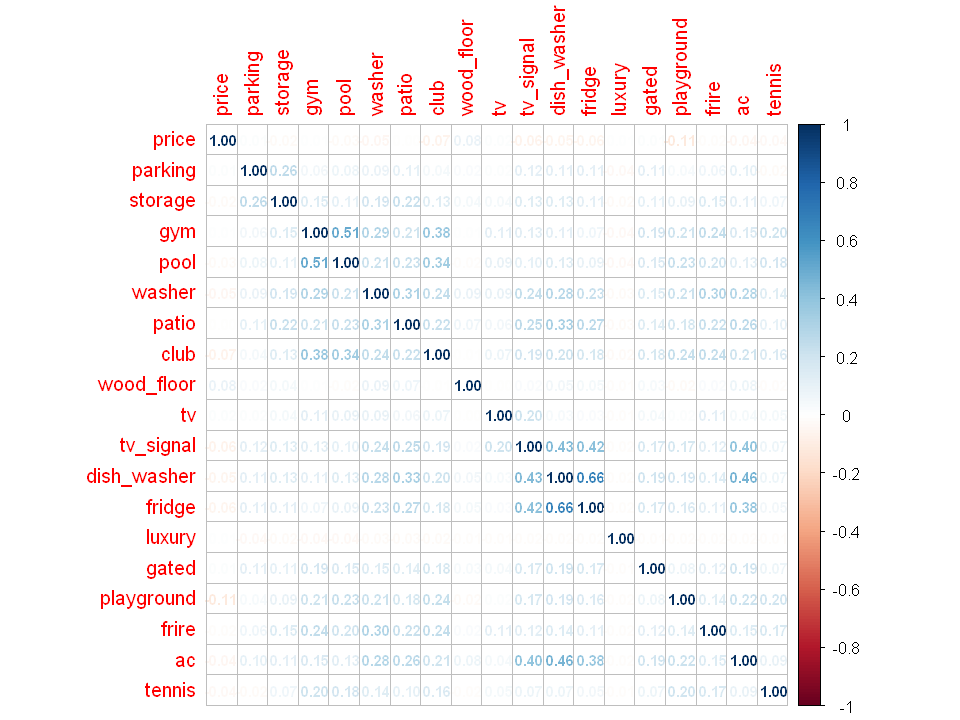

In [13]:
# Amenities (felszereltség) kategória kezelése 2.
# Vizsgáljuk a legtöbbet látott értékeket, hogy valójában hány helyen fordulnak elő

df_amenities = dfc %>%
select(price, amenities) %>%
mutate(parking     = as.numeric(grepl("Parking"           , amenities, fixed = TRUE)),
       storage     = as.numeric(grepl("Storage"           , amenities, fixed = TRUE)),
       gym         = as.numeric(grepl("Gym"               , amenities, fixed = TRUE)),
       pool        = as.numeric(grepl("Pool"              , amenities, fixed = TRUE)),
       washer      = as.numeric(grepl("Washer Dryer"      , amenities, fixed = TRUE)),
       patio       = as.numeric(grepl("Patio/Deck"        , amenities, fixed = TRUE)),
       club        = as.numeric(grepl("Clubhouse"         , amenities, fixed = TRUE)),
       wood_floor  = as.numeric(grepl("Wood Floors"       , amenities, fixed = TRUE)),
       tv          = as.numeric(grepl("TV"                , amenities, fixed = TRUE)),
       tv_signal   = as.numeric(grepl("Cable or Satellite", amenities, fixed = TRUE)),
       dish_washer = as.numeric(grepl("Dishwasher"        , amenities, fixed = TRUE)),
       fridge      = as.numeric(grepl("Refrigerator"      , amenities, fixed = TRUE)),
       luxury      = as.numeric(grepl("Luxury"            , amenities, fixed = TRUE)),
       gated       = as.numeric(grepl("Gated"             , amenities, fixed = TRUE)),
       playground  = as.numeric(grepl("Playground"        , amenities, fixed = TRUE)),
       frire       = as.numeric(grepl("Fireplace"         , amenities, fixed = TRUE)),
       ac          = as.numeric(grepl("AC"                , amenities, fixed = TRUE)),
       tennis      = as.numeric(grepl("Tennis"            , amenities, fixed = TRUE)),
) %>%
select(-amenities)

# Az érintett darabszámok vizsgálata
df_amenities_list = df_amenities %>%
select(-price) %>%
summarise_all(sum)

head(df_amenities_list)

# Korreláció vizsgálata a price-hoz képest
df_amenities %>%
cor() %>%
corrplot(method="number", number.cex=0.75)

# Konklúzió:
# Szinte semmi korreláció nincs a felszereltség és az ár között.
# Ez meglehetősen furcsa, hiszen egy medence esetén azt várnánk,
# hogy mivel az egy luxus szolgáltatás, így drágább is lesz.

In [14]:
# Amenities (felszereltség) kategória kezelése 3.
# A vizsgálat alapján a legjobb korrelációjú felszereltségek felhasználása

dfc = mutate(dfc,
       washer      = factor(grepl("Washer Dryer"      , amenities, fixed = TRUE)),
       club        = factor(grepl("Clubhouse"         , amenities, fixed = TRUE)),
       wood_floor  = factor(grepl("Wood Floors"       , amenities, fixed = TRUE)),
       tv_signal   = factor(grepl("Cable or Satellite", amenities, fixed = TRUE)),
       dish_washer = factor(grepl("Dishwasher"        , amenities, fixed = TRUE)),
       fridge      = factor(grepl("Refrigerator"      , amenities, fixed = TRUE)),
       playground  = factor(grepl("Playground"        , amenities, fixed = TRUE)))

dfc = mutate(dfc,
       washer      = fct_recode(washer     , "No" = "FALSE", "Yes" = "TRUE"),
       club        = fct_recode(club       , "No" = "FALSE", "Yes" = "TRUE"),
       wood_floor  = fct_recode(wood_floor , "No" = "FALSE", "Yes" = "TRUE"),
       tv_signal   = fct_recode(tv_signal  , "No" = "FALSE", "Yes" = "TRUE"),
       dish_washer = fct_recode(dish_washer, "No" = "FALSE", "Yes" = "TRUE"),
       fridge      = fct_recode(fridge     , "No" = "FALSE", "Yes" = "TRUE"),
       playground  = fct_recode(playground , "No" = "FALSE", "Yes" = "TRUE"))

dfc = select(dfc, -amenities)

summary(dfc)

                           category       bathrooms        bedrooms    
 housing/rent                  :    7   Min.   :1.000   Min.   :0.000  
 housing/rent/apartment        :99700   1st Qu.:1.000   1st Qu.:1.000  
 housing/rent/commercial/retail:   42   Median :1.000   Median :2.000  
 housing/rent/condo            :    3   Mean   :1.445   Mean   :1.728  
 housing/rent/home             :    4   3rd Qu.:2.000   3rd Qu.:2.000  
 housing/rent/other            :    1   Max.   :9.000   Max.   :9.000  
 housing/rent/short_term       :    4                                  
  fee            has_photo     pets_allowed     price       price_display  
 No :99560   No       : 9256   Yes:39148    Min.   :  100   Min.   :  100  
 Yes:  201   Thumbnail:34347   No :60613    1st Qu.: 1014   1st Qu.: 1014  
             Yes      :56158                Median : 1350   Median : 1350  
                                            Mean   : 1527   Mean   : 1527  
                                            

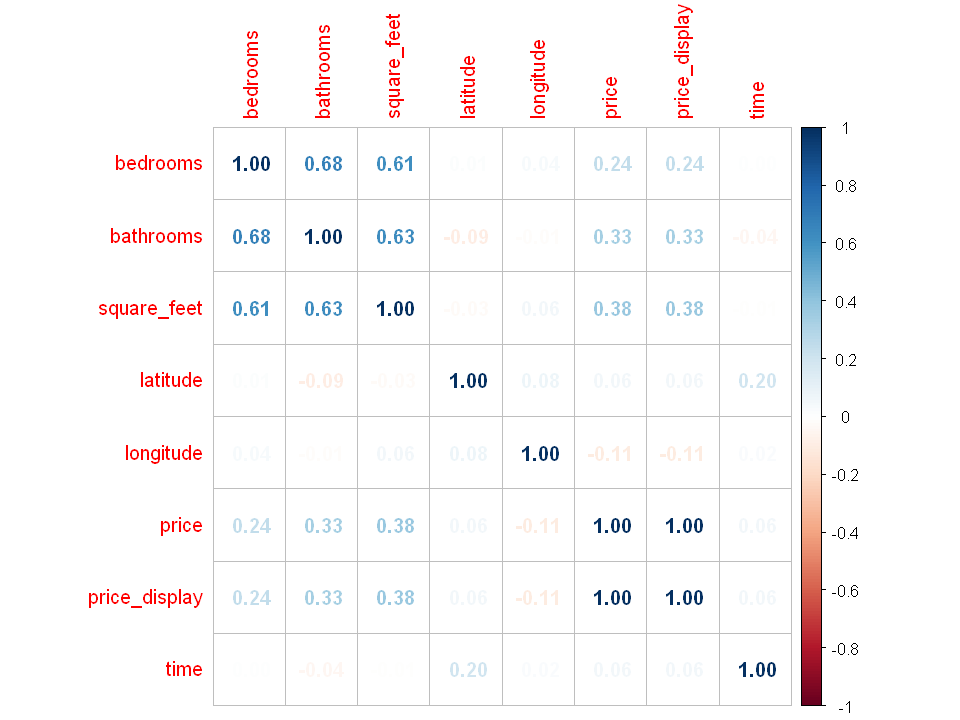

In [15]:
# Numerikus értékek korrelációs vizsgálata

sac_corr = dfc %>% 
select(bedrooms, bathrooms, square_feet, latitude, longitude, price, price_display, time)

mat = cor(sac_corr)
corrplot(mat, method="number")

# Konklúzió:
# Vannak nagyobb korrelációk, pl. háló- és fürdőszobák száma között. Nem szükséges manuális eldobás.

dfc = select(dfc, -price_display)

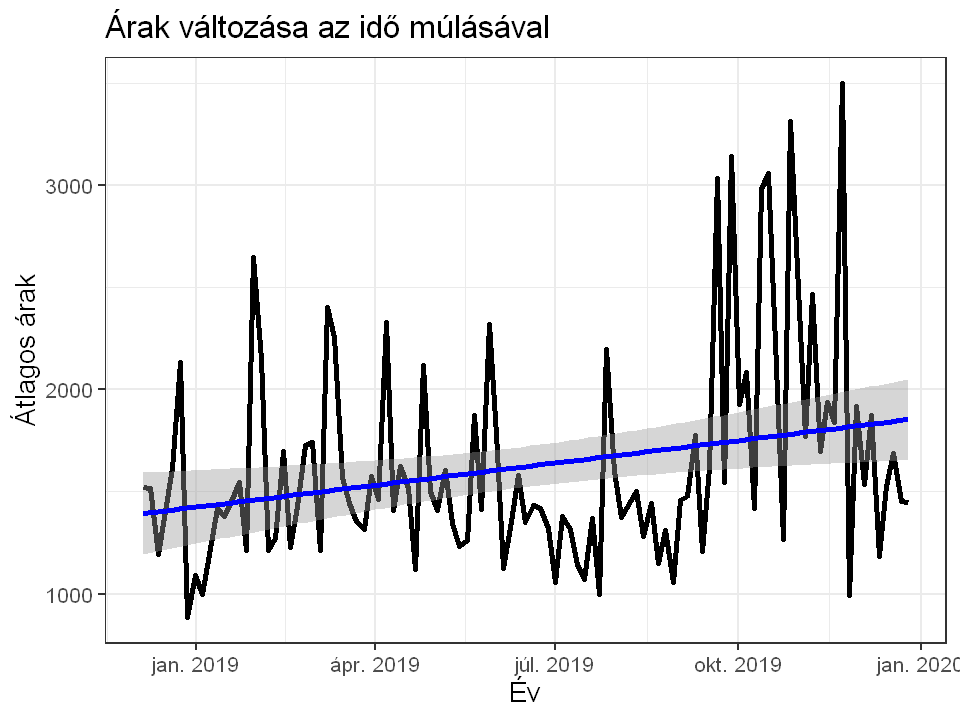

In [47]:
# Árak vizsgálata az idő múlásával

step = 320000

dfc %>%
group_by(tm = as.integer(time/step)) %>%
summarize(atlag_price = mean(price)) %>%
ggplot() + 
geom_line(aes(x = as_datetime(tm*step), y = atlag_price), linewidth = 1.5) + 
geom_smooth(mapping = aes(x = as_datetime(tm*step), y = atlag_price), method='lm', formula = y ~ x, color = 'blue') +
xlab("Év") +
ylab("Átlagos árak") +
ggtitle("Árak változása az idő múlásával") + 
theme_bw(base_size = 16)

# Konklúzió:
# Jól láthatóan növekednek az átlag árak, azonban van egy furcsán nagy ugrás a késő őszi időszakban

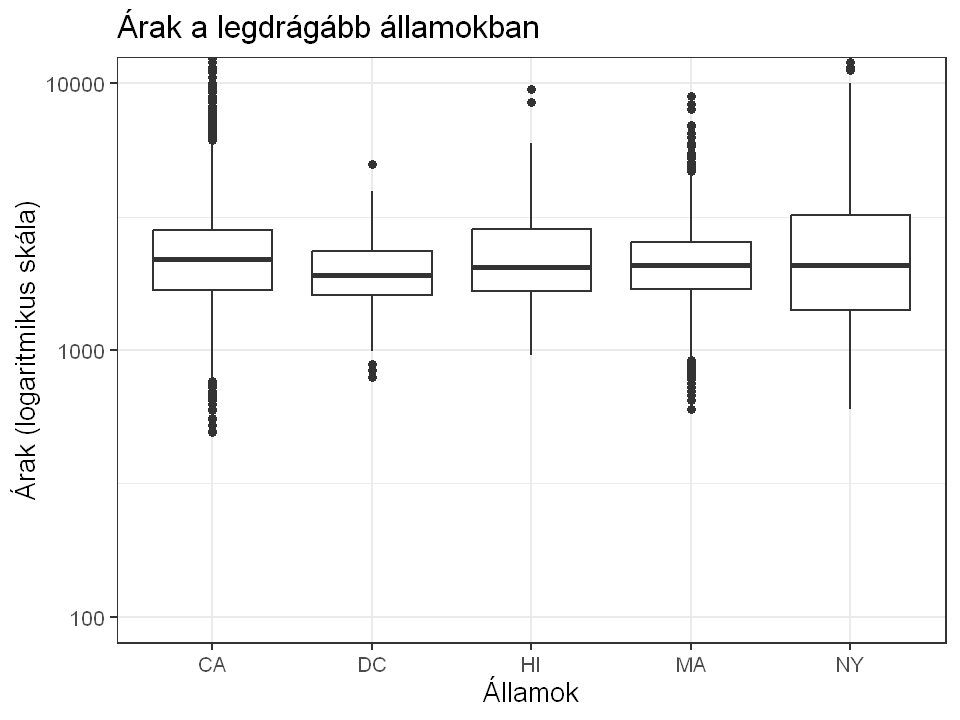

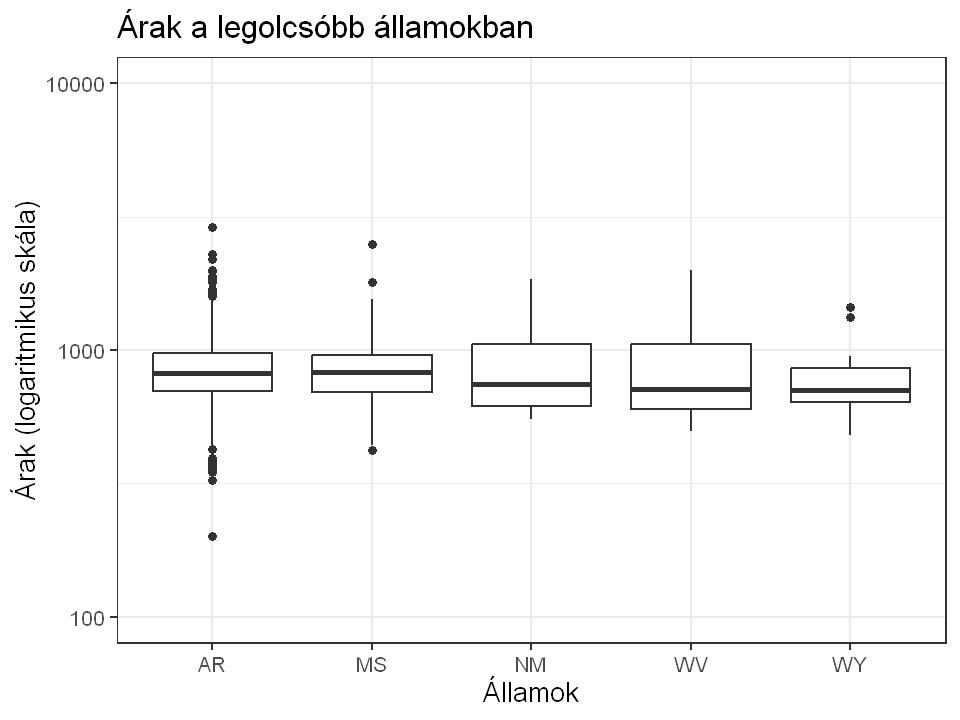

In [51]:
# Árak vizsgálata az egyes államokban (state)

expensive_states = dfc %>%
filter(!is.na(state)) %>%
select(price, state) %>%
group_by(state) %>%
summarize(atlag_price = mean(price)) %>%
arrange(desc(atlag_price))

top = head(expensive_states$state, 5)

cheap_states = expensive_states %>%
arrange(atlag_price)

bot = head(cheap_states$state, 5)

dfc %>%
filter(!is.na(state), state %in% top) %>%
ggplot() + 
geom_boxplot(mapping = aes(x = state, y = price)) +
scale_y_log10() +
coord_cartesian(ylim=c(100, 10000)) +
xlab("Államok") +
ylab("Árak (logaritmikus skála)") +
ggtitle("Árak a legdrágább államokban") + 
theme_bw(base_size = 16)

dfc %>%
filter(!is.na(state), state %in% bot) %>%
ggplot() + 
geom_boxplot(mapping = aes(x = state, y = price)) +
scale_y_log10() +
coord_cartesian(ylim=c(100, 10000)) +
xlab("Államok") +
ylab("Árak (logaritmikus skála)") +
ggtitle("Árak a legolcsóbb államokban") + 
theme_bw(base_size = 16)

# Konklúzió:
# Jól látható, hogy az egyes államokban mekkora különbség érhető el az árak alapján

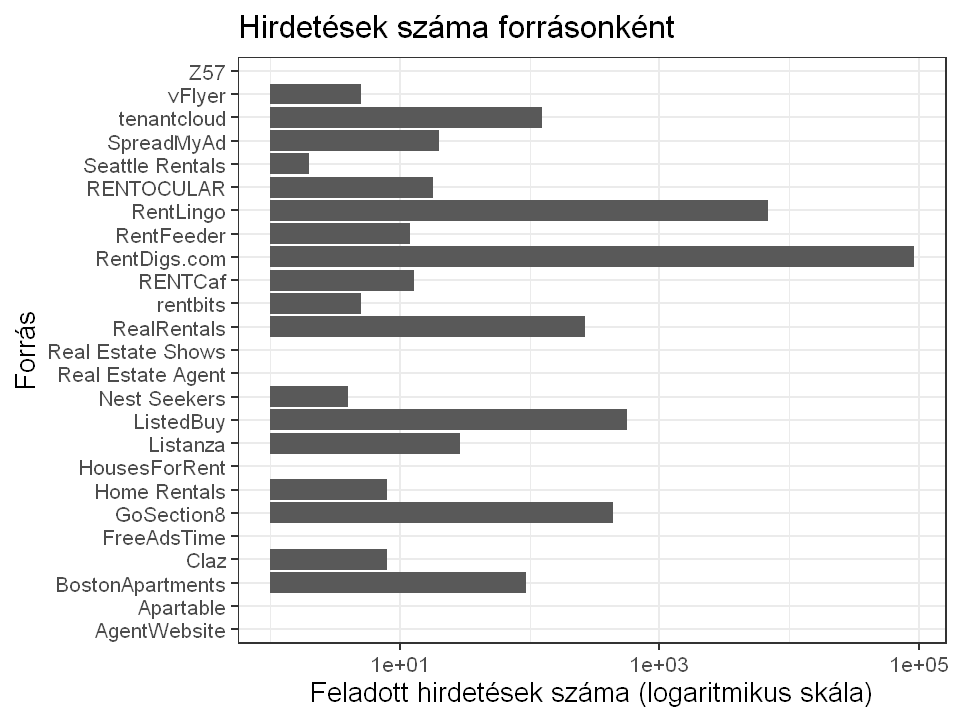

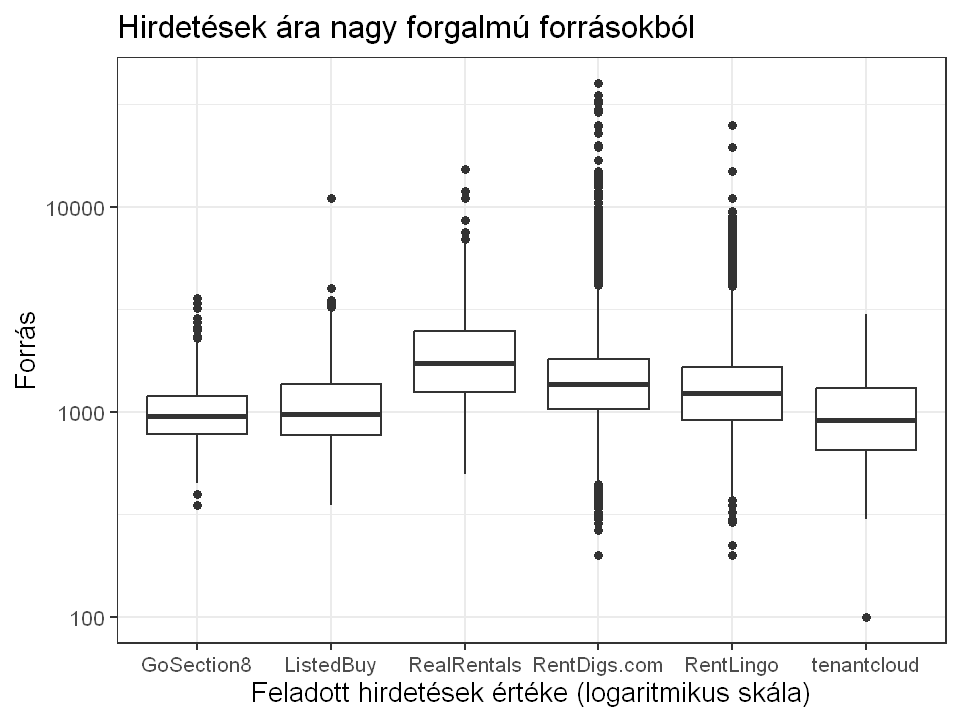

In [52]:
# Források (source) vizsgálata

dfc %>%
filter(!is.na(source)) %>%
select(source) %>%
ggplot() +
geom_bar(mapping = aes(x = source)) +
scale_y_log10() +
xlab("Forrás") +
ylab("Feladott hirdetések száma (logaritmikus skála)") +
ggtitle("Hirdetések száma forrásonként") + 
coord_flip() + 
theme_bw(base_size = 16)

high_traffic = dfc %>%
filter(!is.na(source)) %>%
count(source) %>%
filter(n > 100)

dfc %>%
filter(source %in% high_traffic$source) %>%
select(source, price) %>%
ggplot() +
geom_boxplot(mapping = aes(x = source, y = price)) +
scale_y_log10() +
xlab("Feladott hirdetések értéke (logaritmikus skála)") +
ylab("Forrás") +
ggtitle("Hirdetések ára nagy forgalmú forrásokból") + 
theme_bw(base_size = 16)

# Modellezés

In [49]:
# Modellezés előkészítése - package

library(tidymodels, warn.conflicts=FALSE)
library(tune, warn.conflicts=FALSE)
library(kknn, warn.conflicts=FALSE)
library(ranger, warn.conflicts=FALSE)

set.seed(17)

Warning message:
"package 'ranger' was built under R version 4.5.3"


In [17]:
# Modellezés előkészítése - adatok

dft = dfc

# Felbontás tanító és tesztelő halmazokra
data_split = initial_split(dft, prop=0.75)

df_train = training(data_split)
df_test  = testing(data_split)

nrow(df_train)/nrow(df)

[1] 0.7495041

### Lineáris regresszió

In [20]:
# Egyszerű modell, benchmarknak

# Recept
linear_recept = recipe(price ~ ., data=df_train) %>%
    step_integer(category) %>%
    step_integer(fee) %>%
    step_integer(has_photo) %>%
    step_integer(pets_allowed) %>%
    step_integer(cityname) %>%
    step_integer(state) %>%
    step_integer(source) %>%
    step_integer(washer) %>%
    step_integer(club) %>%
    step_integer(wood_floor) %>%
    step_integer(tv_signal) %>%
    step_integer(dish_washer) %>%
    step_integer(fridge) %>%
    step_integer(playground) %>%
    step_corr(all_numeric_predictors(), threshold = .9) %>%
    prep()

# Tanítás
fit_linear = linear_reg() %>%
set_engine("lm") %>%
set_mode("regression") %>% 
fit(price ~ ., data = bake(linear_recept, df_train))

# Tesztelés
linear_pred = fit_linear %>%
predict(bake(linear_recept, df_test)) %>%
bind_cols(df_test) %>%
select(price, .pred)

rsq(linear_pred, price, .pred)
rmse(linear_pred, price, .pred)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rsq,standard,0.2124335


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,843.747


### KNN

In [118]:
# Komplexebb modell, de nem használ factor-okat

knn_mod = 
    nearest_neighbor(neighbors = tune()) %>% 
    set_engine("kknn") %>% 
    set_mode("regression")

# Recept, ahol csak numerikus értékek szerepelnek
# Factor-ok ki vannak hagyva, hogy a távolságoknak legyen értelme,
# és ne legyen felesleges rendeződés az értékeik között
knn_recept =
    recipe(price ~ square_feet + bathrooms + bedrooms + latitude + longitude + time, data=dft) %>%
    step_center(square_feet, bathrooms, bedrooms, latitude, longitude, time) %>%
    step_scale(square_feet, bathrooms, bedrooms, latitude, longitude, time)

cv_splits = vfold_cv(dft)

knn_grid = expand.grid(neighbors=1:30)

# Paraméter tuning
knn_tune = tune_grid(
    knn_mod,
    knn_recept,
    resample=cv_splits,
    grid = knn_grid,
)

In [119]:
# KNN modell 2

knn_tune %>% 
collect_metrics() %>%
head()

neighbors,.metric,.estimator,mean,n,std_err,.config
<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,rmse,standard,610.5372903,10,27.61480089,pre0_mod01_post0
1,rsq,standard,0.5878008,10,0.01778165,pre0_mod01_post0
2,rmse,standard,568.7608652,10,25.66164643,pre0_mod02_post0
2,rsq,standard,0.6225735,10,0.01613781,pre0_mod02_post0
3,rmse,standard,543.1529817,10,24.27335501,pre0_mod03_post0
3,rsq,standard,0.6442826,10,0.01440789,pre0_mod03_post0


In [23]:
#xd kivenni
knn_tune = tibble(
    neighbors = c(1, 1, 2, 2, 3, 3),
    .metric = c("rmse", "rsq", "rmse", "rsq", "rmse", "rsq"),
    mean = c(610.5372903, 0.5878008, 568.7608652, 0.6225735, 543.1529817, 0.6442826)
)

head(knn_tune)

neighbors,.metric,mean
<dbl>,<chr>,<dbl>
1,rmse,610.5372903
1,rsq,0.5878008
2,rmse,568.7608652
2,rsq,0.6225735
3,rmse,543.1529817
3,rsq,0.6442826


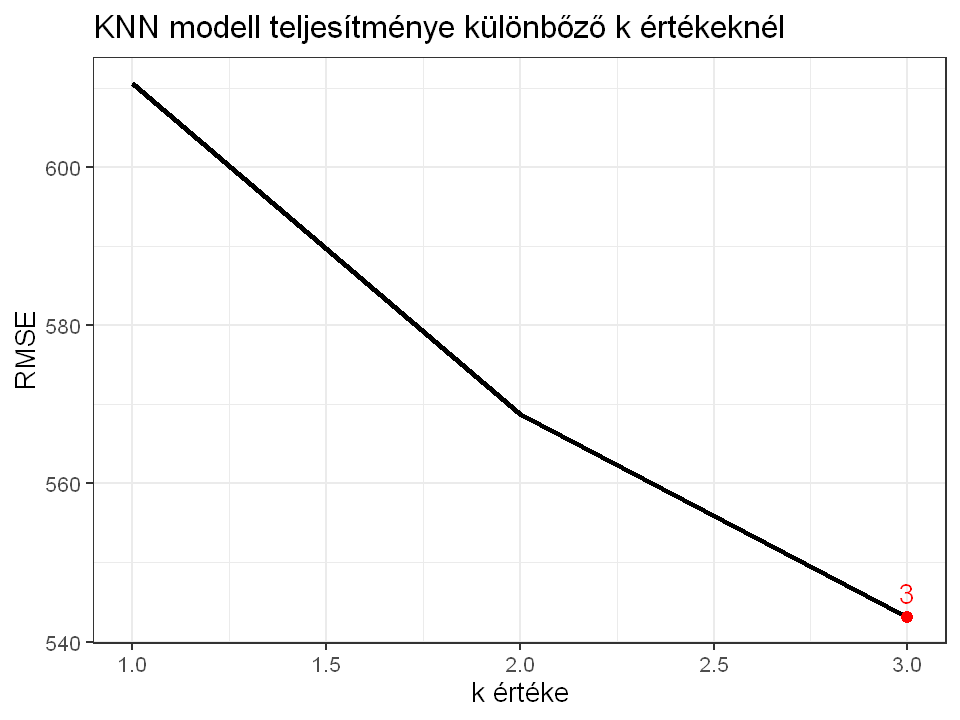

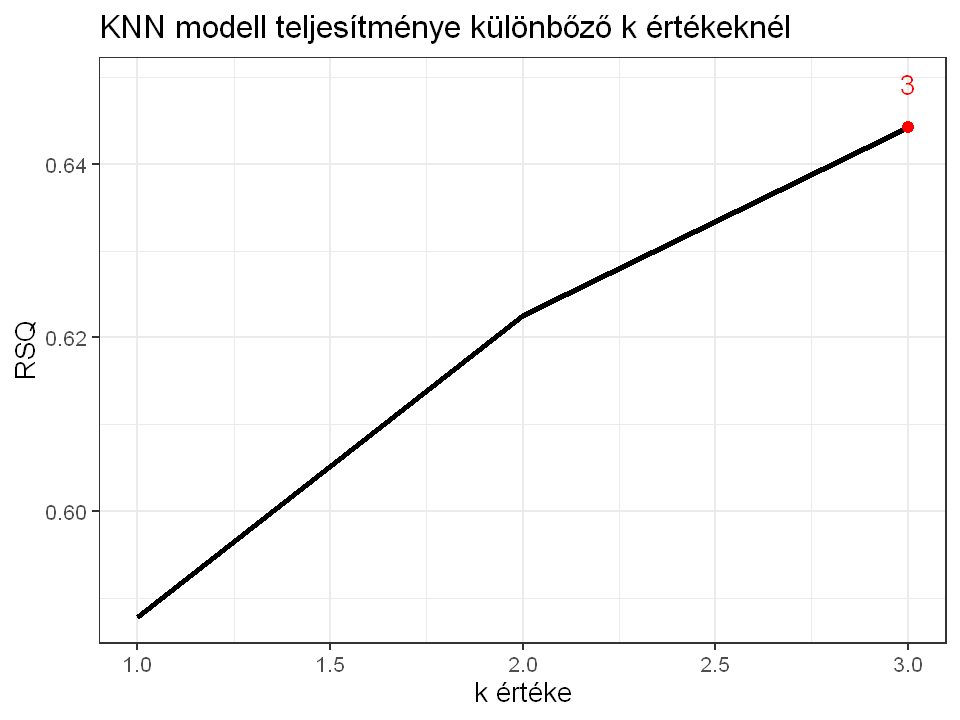

In [44]:
# KNN modell 2

knn_preds = knn_tune #%>%
#collect_metrics()


min_rmse = knn_preds %>%
filter(.metric=='rmse') %>%
arrange(mean) %>%
head(1)

max_rsq = knn_preds %>%
filter(.metric=='rsq') %>%
arrange(desc(mean)) %>%
head(1)

# Paraméter tuning eredményének kiértékelése
knn_preds %>%
filter(.metric=='rmse') %>%
ggplot() +
geom_line(aes(x = neighbors, y = mean), linewidth = 1.5) + 
annotate("point", x = min_rmse$neighbors, y = min_rmse$mean, colour = "red", size = 3) +
annotate("text", x = min_rmse$neighbors, y = min_rmse$mean+3, colour = "red", size = 6, label = min_rmse$neighbors) +
#coord_cartesian(ylim=c(220,270)) +
xlab("k értéke") +
ylab("RMSE") +
ggtitle("KNN modell teljesítménye különbőző k értékeknél") + 
theme_bw(base_size = 16)

knn_preds %>%
filter(.metric=='rsq') %>%
ggplot() +
geom_line(aes(x = neighbors, y = mean), linewidth = 1.5) + 
annotate("point", x = max_rsq$neighbors, y = max_rsq$mean, colour = "red", size = 3) +
annotate("text", x = max_rsq$neighbors, y = max_rsq$mean+0.005, colour = "red", size = 6, label = max_rsq$neighbors) +
#coord_cartesian(ylim=c(220,270)) +
xlab("k értéke") +
ylab("RSQ") +
ggtitle("KNN modell teljesítménye különbőző k értékeknél") + 
theme_bw(base_size = 16)

In [45]:
# Modell TODO?

recept = dft %>%
recipe(price ~ .) %>%
  step_integer(category) %>%
  step_integer(fee) %>%
  step_integer(has_photo) %>%
  step_integer(pets_allowed) %>%
  step_integer(cityname) %>%
  step_integer(state) %>%
  step_integer(source) %>%
  step_integer(parking) %>%
  step_integer(pool) %>%
  step_integer(gym) %>%
  step_integer(patio) %>%
  step_integer(washer) %>%
step_corr(all_numeric_predictors(), threshold = .9)

#tidy(recept)

#recept %>%
#bake(new_data = NULL) %>%
#head(2)

In [51]:
model = rand_forest(mode = "regression", trees=50, mtry=2) %>%
  set_engine('ranger')

wflow = workflow() %>% 
  add_model(model) %>% 
  add_formula(price ~ .)

cv_splits = vfold_cv(dft)

eval = fit_resamples(wflow, resamples = cv_splits, control = control_resamples(save_pred = TRUE))
collect_metrics(eval)

.metric,.estimator,mean,n,std_err,.config
<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
rmse,standard,516.2803389,10,23.253232123,pre0_mod0_post0
rsq,standard,0.7252598,10,0.006382612,pre0_mod0_post0


In [ ]:
# Komplexebb modell, de nem használ factor-okat

rf_mod = 
    rand_forest(mode = "regression", trees=tune(), mtry=tune()) %>%
    set_engine('ranger')

rf_recept = recipe(price ~ ., data=dft) %>%
    step_integer(category) %>%
    step_integer(fee) %>%
    step_integer(has_photo) %>%
    step_integer(pets_allowed) %>%
    step_integer(cityname) %>%
    step_integer(state) %>%
    step_integer(source) %>%
    step_integer(washer) %>%
    step_integer(club) %>%
    step_integer(wood_floor) %>%
    step_integer(tv_signal) %>%
    step_integer(dish_washer) %>%
    step_integer(fridge) %>%
    step_integer(playground) %>%
    step_corr(all_numeric_predictors(), threshold = .9)

cv_splits = vfold_cv(dft)

rf_grid = expand.grid(trees=10:20*10, mtry=2:5)

# Paraméter tuning
rf_tune = tune_grid(
    rf_mod,
    rf_recept,
    resample = cv_splits,
    grid = rf_grid,
)

→ A | error:   Error: Invalid forest object.

There were issues with some computations   A: x1


In [56]:
rf_tune %>% 
collect_metrics() %>%
head()

mtry,trees,.metric,.estimator,mean,n,std_err,.config
<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
2,30,rmse,standard,514.5878852,10,16.792634867,pre0_mod1_post0
2,30,rsq,standard,0.7219309,10,0.009853784,pre0_mod1_post0


In [65]:
asdf <- 10:20*10

asdf

[1] 100 110 120 130 140 150 160 170 180 190 200